In [1]:
import kagglehub
kellysanderson_myopia_image_dataset_path = kagglehub.dataset_download('kellysanderson/myopia-image-dataset')

print('Data source import complete.')


Data source import complete.


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from sklearn.model_selection import train_test_split

In [3]:
BASE_DIR = '/kaggle/input/myopia-image-dataset/IMAGES'

In [4]:
import os
import pandas as pd
import random
from tqdm import tqdm

# Initialize lists to store image paths and labels
image_paths = []
labels = []

# Iterate through subdirectories
for label in ["Myopia_images", "Normal_images"]:
    class_dir = os.path.join(BASE_DIR, label)
    if os.path.exists(class_dir):  # Ensure directory exists
        all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Select only 15% of the images
        sample_size = max(1, int(0.15 * len(all_files)))  # Ensure at least 1 image is selected
        sampled_files = random.sample(all_files, sample_size)  # Randomly select 15% of images
        
        # Process sampled files
        for filename in tqdm(sampled_files, desc=f"Processing {label}"):
            image_path = os.path.join(class_dir, filename)
            image_paths.append(image_path)
            labels.append(label)  # Store label

# Create DataFrame
df = pd.DataFrame({'image': image_paths, 'label': labels})

Processing Normal_images: 100%|██████████| 9225/9225 [00:00<00:00, 519989.98it/s]


In [5]:
label_mapping = {'Normal_images': 0, 'Myopia_images': 1}
df['label_encoded'] = df['label'].map(label_mapping)

In [6]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

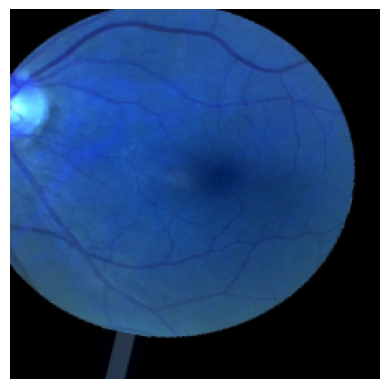

In [7]:
from PIL import Image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img);

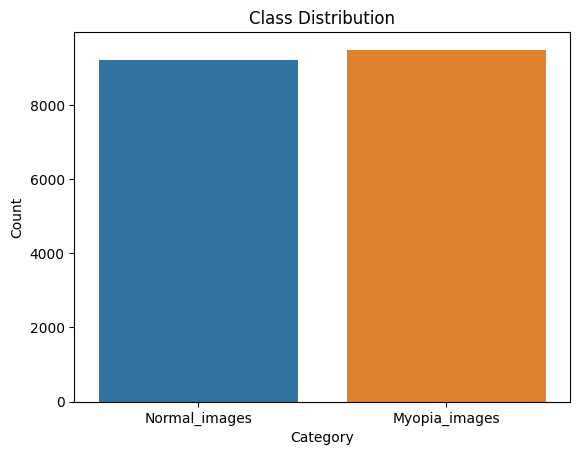

In [8]:
sns.countplot(x=df['label'])  # Use x= instead of passing df['label'] directly
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [9]:
num_images = 10
df_normal = df[df['label'] == 'Normal_images'].sample(n=num_images, random_state=42)
df_myopia = df[df['label'] == 'Myopia_images'].sample(n=num_images, random_state=42)

# Combine both classes
df_balanced = pd.concat([df_normal, df_myopia]).reset_index(drop=True)

In [10]:
myopia_dict = {0: 'Normal', 1: 'Myopia'} 

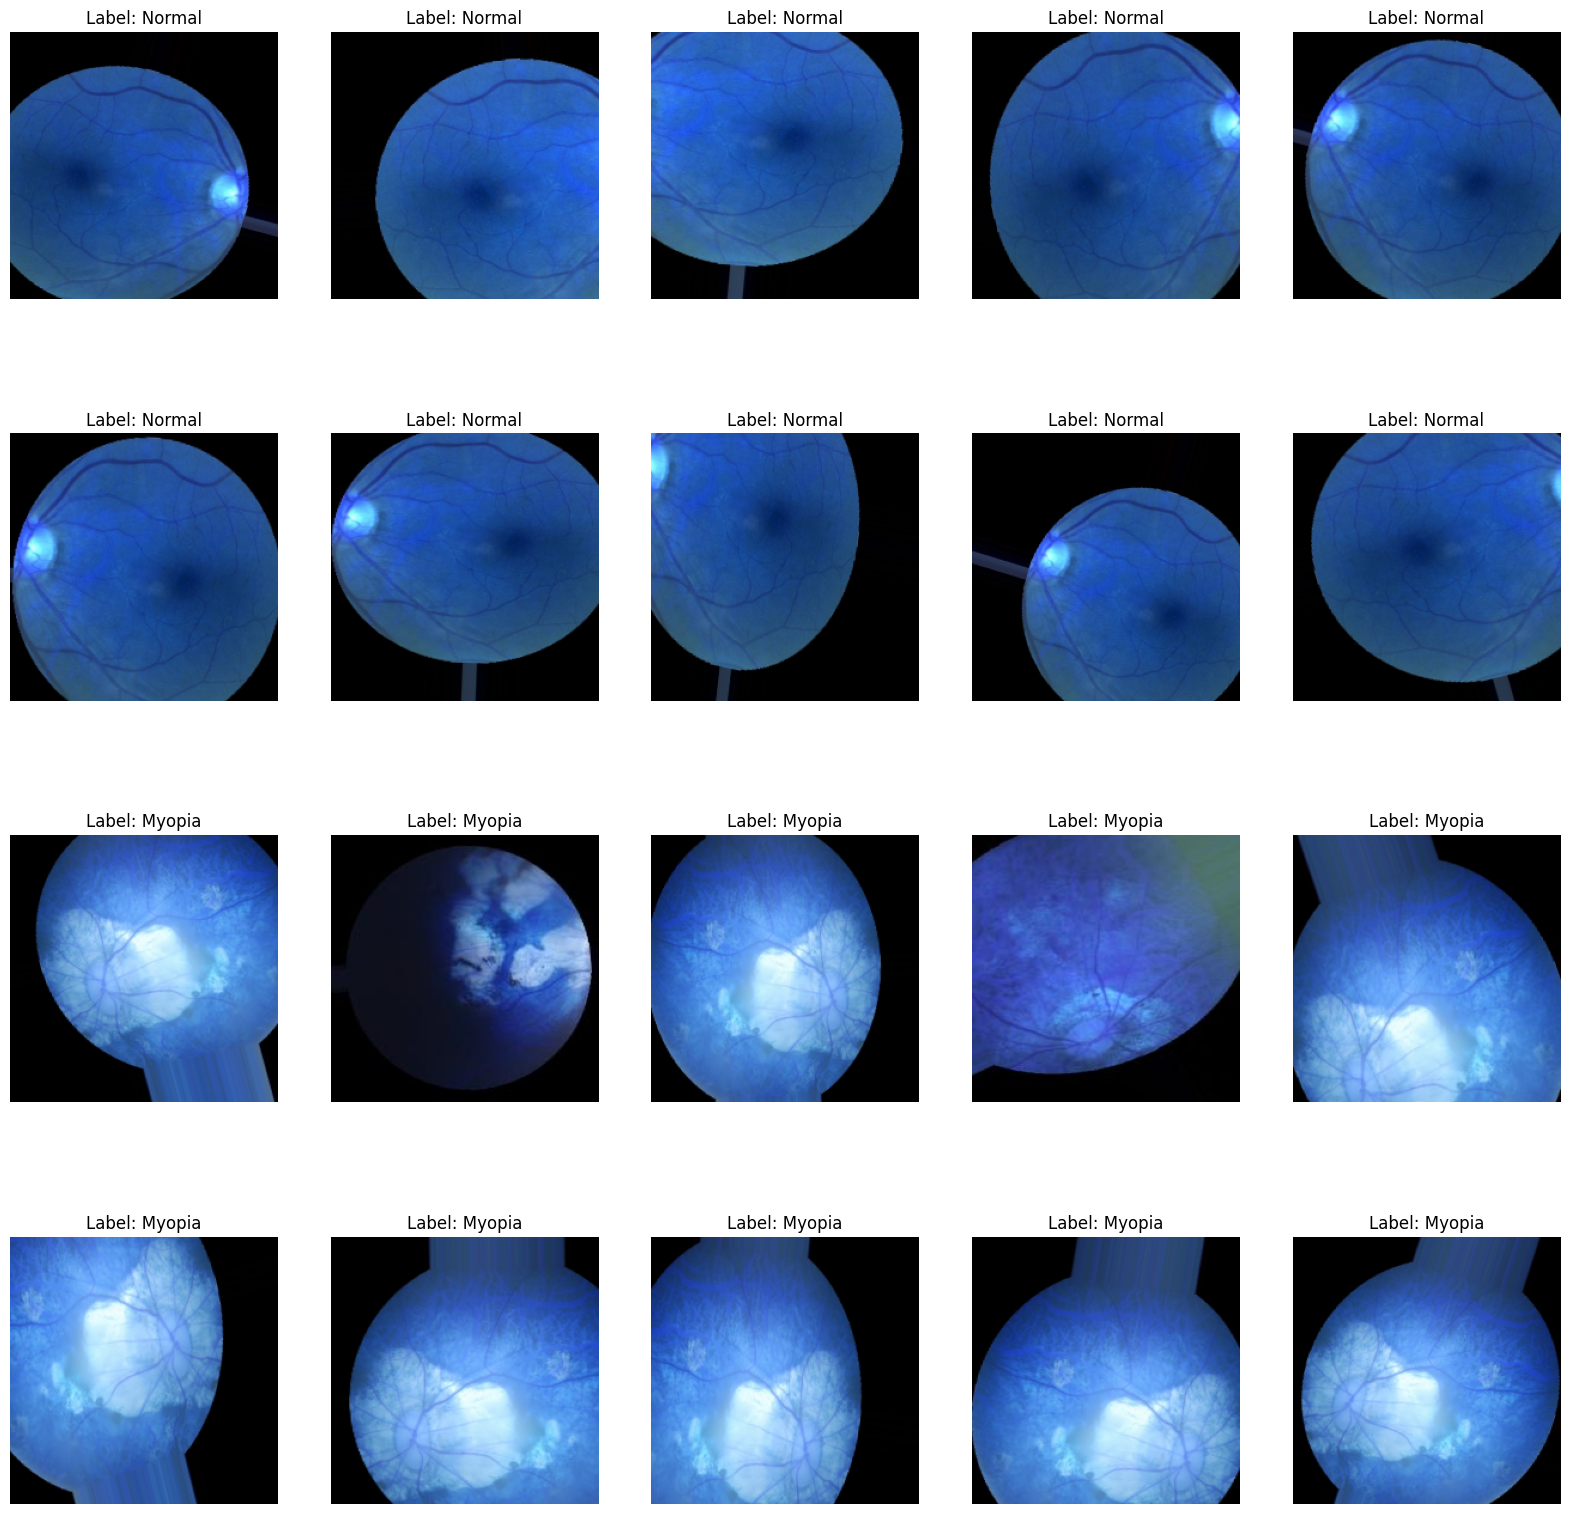

In [11]:
plt.figure(figsize=(20, 20))
for index, row in df_balanced.iterrows():
    plt.subplot(4, 5, index + 1)  # Create a 5x4 grid
    img = load_img(row['image'])  # Load image
    img = np.array(img)  # Convert to numpy array
    plt.imshow(img)
    plt.title(f"Label: {myopia_dict[row['label_encoded']]}")
    plt.axis('off')

plt.show()

In [12]:
from keras.preprocessing.image import load_img
import numpy as np
from tqdm import tqdm
from PIL import Image

def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='rgb')
        img = img.resize((128, 128), Image.Resampling.LANCZOS)  # Adjust based on Pillow version
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 128, 128, 3)
    return features

In [13]:
X = extract_features(df['image'])

100%|██████████| 18719/18719 [02:40<00:00, 116.53it/s]


In [14]:
X.shape

(18719, 128, 128, 3)

In [15]:
X = X/255.0 

In [16]:
Y = np.array(df['label_encoded'])

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [18]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

In [19]:
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 13477
Validation samples: 1498
Test samples: 3744


Processing Myopia_images:   0%|          | 0/9494 [00:00<?, ?it/s]

Processing Normal_images:   0%|          | 0/9225 [00:00<?, ?it/s]

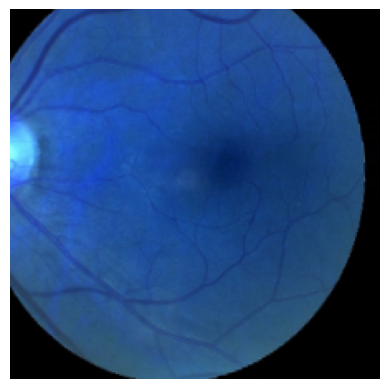

In [20]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
from PIL import Image

warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split

# Define base directory
BASE_DIR = '/kaggle/input/myopia-image-dataset/IMAGES'

# Mapping for labels
label_mapping = {'Normal_images': 0, 'Myopia_images': 1}

# Initialize lists to store image paths and labels
image_paths = []
labels = []

# Iterate through both classes and sample 15% images
for label in ["Myopia_images", "Normal_images"]:
    class_dir = os.path.join(BASE_DIR, label)
    if os.path.exists(class_dir):
        all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sample_size = max(1, int(0.15 * len(all_files)))
        sampled_files = random.sample(all_files, sample_size)

        for filename in tqdm(sampled_files, desc=f"Processing {label}"):
            image_path = os.path.join(class_dir, filename)
            image_paths.append(image_path)
            labels.append(label_mapping[label])  # Use encoded label

# Create DataFrame
df = pd.DataFrame({'image': image_paths, 'label': labels})

# Shuffle the DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Visualize a sample image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img)
plt.show()


In [21]:
IMG_SIZE = 224  # CoAtNet requires 224x224 input

def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0  # Normalize
    return image, label


In [22]:
paths = df['image'].values
labels = df['label'].values

# Split
train_paths, val_paths, train_labels, val_labels = train_test_split(paths, labels, test_size=0.2, random_state=42)

# TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = train_ds.map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)


In [23]:
!pip install -q git+https://github.com/rwightman/pytorch-image-models.git


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [24]:
from tensorflow.keras import layers, models

def coatnet(input_shape=(224, 224, 3), num_classes=2):
    inputs = layers.Input(shape=input_shape)

    # Simple Conv Blocks
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Attention Block (simplified)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = coatnet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 112, 112, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,186 (364.01 KB)

 Trainable params: 92,802 (362.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [25]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import tensorflow as tf
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline


Processing Myopia_images:   0%|          | 0/9494 [00:00<?, ?it/s]

Processing Normal_images:   0%|          | 0/9225 [00:00<?, ?it/s]

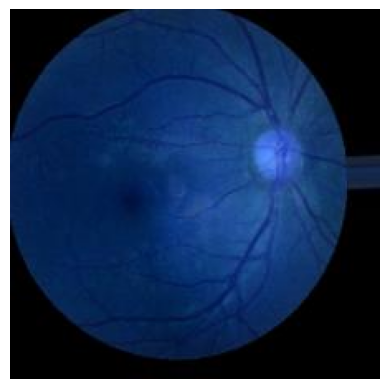

In [26]:
BASE_DIR = '/kaggle/input/myopia-image-dataset/IMAGES'
label_mapping = {'Normal_images': 0, 'Myopia_images': 1}

image_paths = []
labels = []

for label in ["Myopia_images", "Normal_images"]:
    class_dir = os.path.join(BASE_DIR, label)
    if os.path.exists(class_dir):
        all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sample_size = max(1, int(0.15 * len(all_files)))
        sampled_files = random.sample(all_files, sample_size)

        for filename in tqdm(sampled_files, desc=f"Processing {label}"):
            image_paths.append(os.path.join(class_dir, filename))
            labels.append(label_mapping[label])

df = pd.DataFrame({'image': image_paths, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Visualize one image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img)
plt.show()


In [27]:
IMG_SIZE = 224

def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0
    return image, label


In [28]:
paths = df['image'].values
labels = df['label'].values

train_paths, val_paths, train_labels, val_labels = train_test_split(paths, labels, test_size=0.2, random_state=42)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)).map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)).map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)


In [29]:
from tensorflow.keras import layers, models

def coatnet(input_shape=(224, 224, 3), num_classes=2):
    inputs = layers.Input(shape=input_shape)
    
    # Convolution Blocks
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Simulated Attention (via GAP + Dense)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = coatnet()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,186 (364.01 KB)

 Trainable params: 92,802 (362.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("coatnet_best_model.keras", save_best_only=True),
        tf.keras.callbacks.CSVLogger("training_log.csv")
    ]
)


Epoch 1/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - accuracy: 0.9463 - loss: 0.1481 - val_accuracy: 0.9538 - val_loss: 0.1204
Epoch 2/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 674s 1s/step - accuracy: 0.9712 - loss: 0.0772 - val_accuracy: 0.9169 - val_loss: 0.2684
Epoch 3/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 653s 1s/step - accuracy: 0.9757 - loss: 0.0667 - val_accuracy: 0.9388 - val_loss: 0.1757
Epoch 4/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 691s 1s/step - accuracy: 0.9774 - loss: 0.0583 - val_accuracy: 0.8467 - val_loss: 0.3612
Epoch 5/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 659s 1s/step - accuracy: 0.9801 - loss: 0.0530 - val_accuracy: 0.9776 - val_loss: 0.0530


In [31]:
from tensorflow.keras import layers, models
import tensorflow as tf

# MBConv block (depthwise separable convolution + squeeze-excitation)
def MBConv(x, filters, expansion=4):
    input_channels = x.shape[-1]
    expanded_channels = input_channels * expansion

    # Expansion phase
    x1 = layers.Conv2D(expanded_channels, 1, padding='same', use_bias=False)(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation('swish')(x1)

    # Depthwise convolution
    x1 = layers.DepthwiseConv2D(kernel_size=3, padding='same', use_bias=False)(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation('swish')(x1)

    # Squeeze and Excitation
    se = layers.GlobalAveragePooling2D()(x1)
    se = layers.Dense(expanded_channels // 4, activation='relu')(se)
    se = layers.Dense(expanded_channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, expanded_channels))(se)
    x1 = layers.Multiply()([x1, se])

    # Projection
    x1 = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x1)
    x1 = layers.BatchNormalization()(x1)

    # Skip connection
    if input_channels == filters:
        x1 = layers.Add()([x, x1])

    return x1

# Simple Transformer block using MHSA (Multi-Head Self-Attention)
def TransformerBlock(x, num_heads, key_dim):
    input_shape = tf.shape(x)
    B, H, W, C = x.shape

    # Flatten spatial dims
    x_flat = layers.Reshape((H * W, C))(x)

    # LayerNorm + MHSA
    x1 = layers.LayerNormalization(epsilon=1e-6)(x_flat)
    x1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x1, x1)

    # Residual connection
    x2 = layers.Add()([x_flat, x1])

    # Feed Forward Network
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(C * 4, activation='relu')(x3)
    x3 = layers.Dense(C)(x3)

    # Add & reshape
    x_out = layers.Add()([x2, x3])
    x_out = layers.Reshape((H, W, C))(x_out)
    return x_out

# Full CoAtNet-style model
def build_coatnet(input_shape=(224, 224, 3), num_classes=2):
    inputs = layers.Input(shape=input_shape)

    # Stem conv
    x = layers.Conv2D(64, 3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # Stage 1: MBConv blocks
    for _ in range(2):
        x = MBConv(x, filters=64)

    # Stage 2: MBConv blocks
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    for _ in range(2):
        x = MBConv(x, filters=128)

    # Stage 3: Transformer block
    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = TransformerBlock(x, num_heads=4, key_dim=64)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

# Instantiate model
coatnet_model = build_coatnet()
coatnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
coatnet_model.summary()


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
import matplotlib.pyplot as plt

# Extract values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plotting
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Myopia']

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import random

# Show 9 predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    idx = random.randint(0, len(val_paths) - 1)
    img_path = val_paths[idx]
    true_label = y_true[idx]
    pred_label = y_pred[idx]

    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    title_color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label} | Pred: {pred_label}", color=title_color)

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Input shape based on your dataset
IMG_SIZE = (224, 224)
NUM_CLASSES = 2

# Load base ResNet50 model (without top), use imagenet weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # Freeze base model initially

# Build custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
pip install ultralytics


In [ ]:
from ultralytics import YOLO

# Load the model - start from a pre-trained model
model = YOLO('yolov8n.pt')  # You can choose 'n', 's', 'm', 'l', 'x' variants

# Train the model
model.train(data='data.yaml', epochs=50, imgsz=640, batch=8)


In [ ]:
import os
import shutil
import random
from pathlib import Path

# Original dataset path
dataset_path = Path("/kaggle/input/myopia-image-dataset/IMAGES")
classes = ["myopia", "non-myopia"]

# Create new folders
base_path = Path("/kaggle/working/dataset")
train_path = base_path / "train"
val_path = base_path / "val"

for cls in classes:
    os.makedirs(train_path / cls, exist_ok=True)
    os.makedirs(val_path / cls, exist_ok=True)

# Split ratio
split_ratio = 0.8

# Copy images to train and val folders
for cls in classes:
    src_dir = dataset_path / cls
    images = list(src_dir.glob("*.jpg")) + list(src_dir.glob("*.png"))
    random.shuffle(images)
    
    split_idx = int(len(images) * split_ratio)
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    for img in train_imgs:
        shutil.copy(img, train_path / cls / img.name)
    
    for img in val_imgs:
        shutil.copy(img, val_path / cls / img.name)

print("✅ Dataset prepared in YOLOv8 classification format.")


In [ ]:
from pathlib import Path

# Path to your folder
folder = Path("/kaggle/working/dataset/train/myopia")

# List all .jpg images
image_files = list(folder.glob("*.jpg"))

# Print image count
print(f"Total .jpg images in myopia/train: {len(image_files)}")

# Optionally print a few image names
print("Example images:", image_files[:3])
